# UWB Distance Estimation (Regression)

This notebook uses several regression algorithms for distance estimator for two dominant shortest paths

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Load Regression Data generated from preprocessing pipeline
data = np.load('multi_regression_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (33600, 104)
y_train shape: (33600, 2)
X_test shape: (8400, 104)
y_test shape: (8400, 2)


## 1. Random Forest Regressor
A strong baseline ensemble learning method.

In [2]:
base_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf = MultiOutputRegressor(base_rf)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse1 = np.sqrt(mean_squared_error(y_test[:, 0], rf_preds[:, 0]))
rf_mae1 = mean_absolute_error(y_test[:, 0], rf_preds[:, 0])
rf_r21 = r2_score(y_test[:, 0], rf_preds[:, 0])

rf_rmse2 = np.sqrt(mean_squared_error(y_test[:, 1], rf_preds[:, 1]))
rf_mae2 = mean_absolute_error(y_test[:, 1], rf_preds[:, 1])
rf_r22 = r2_score(y_test[:, 1], rf_preds[:, 1])

print("Random Forest Performance:")
print(f"Path 1 - RMSE: {rf_rmse1:.4f} | MAE: {rf_mae1:.4f} | R2: {rf_r21:.4f}")
print(f"Path 2 - RMSE: {rf_rmse2:.4f} | MAE: {rf_mae2:.4f} | R2: {rf_r22:.4f}")

Random Forest Performance:
Path 1 - RMSE: 1.1497 | MAE: 0.8536 | R2: 0.7595
Path 2 - RMSE: 1.3908 | MAE: 1.0165 | R2: 0.7993


## 2. HistGradientBoosting Regressor
A faster, highly performant gradient boosting implementation optimized for large tabular datasets.

In [3]:
base_hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=10, random_state=42)
hgb = MultiOutputRegressor(base_hgb)
hgb.fit(X_train, y_train)

hgb_preds = hgb.predict(X_test)

hgb_rmse1 = np.sqrt(mean_squared_error(y_test[:, 0], hgb_preds[:, 0]))
hgb_mae1 = mean_absolute_error(y_test[:, 0], hgb_preds[:, 0])
hgb_r21 = r2_score(y_test[:, 0], hgb_preds[:, 0])

hgb_rmse2 = np.sqrt(mean_squared_error(y_test[:, 1], hgb_preds[:, 1]))
hgb_mae2 = mean_absolute_error(y_test[:, 1], hgb_preds[:, 1])
hgb_r22 = r2_score(y_test[:, 1], hgb_preds[:, 1])

print("HistGradientBoosting Performance:")
print(f"Path 1 - RMSE: {hgb_rmse1:.4f} | MAE: {hgb_mae1:.4f} | R2: {hgb_r21:.4f}")
print(f"Path 2 - RMSE: {hgb_rmse2:.4f} | MAE: {hgb_mae2:.4f} | R2: {hgb_r22:.4f}")

HistGradientBoosting Performance:
Path 1 - RMSE: 1.1392 | MAE: 0.8577 | R2: 0.7639
Path 2 - RMSE: 1.3526 | MAE: 1.0026 | R2: 0.8102


## 3. Multi-layer Perceptron (MLP) Regressor
A neural network regressor capturing complex, non-linear relationships via hidden layers.

In [4]:
base_mlp = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', 
                   early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, 
                   max_iter=500, random_state=42)
mlp = MultiOutputRegressor(base_mlp)
mlp.fit(X_train, y_train)

mlp_preds = mlp.predict(X_test)

mlp_rmse1 = np.sqrt(mean_squared_error(y_test[:, 0], mlp_preds[:, 0]))
mlp_mae1 = mean_absolute_error(y_test[:, 0], mlp_preds[:, 0])
mlp_r21 = r2_score(y_test[:, 0], mlp_preds[:, 0])

mlp_rmse2 = np.sqrt(mean_squared_error(y_test[:, 1], mlp_preds[:, 1]))
mlp_mae2 = mean_absolute_error(y_test[:, 1], mlp_preds[:, 1])
mlp_r22 = r2_score(y_test[:, 1], mlp_preds[:, 1])

print("MLPRegressor Performance:")
print(f"Path 1 - RMSE: {mlp_rmse1:.4f} | MAE: {mlp_mae1:.4f} | R2: {mlp_r21:.4f}")
print(f"Path 2 - RMSE: {mlp_rmse2:.4f} | MAE: {mlp_mae2:.4f} | R2: {mlp_r22:.4f}")

MLPRegressor Performance:
Path 1 - RMSE: 1.1761 | MAE: 0.8931 | R2: 0.7484
Path 2 - RMSE: 1.4346 | MAE: 1.0744 | R2: 0.7865


## Visualization: Model Comparison by Metric
Side-by-side grouped bar charts comparing RMSE, MAE, and R² across all three models for both Path 1 and Path 2.
Lower RMSE/MAE and higher R² indicate better performance.

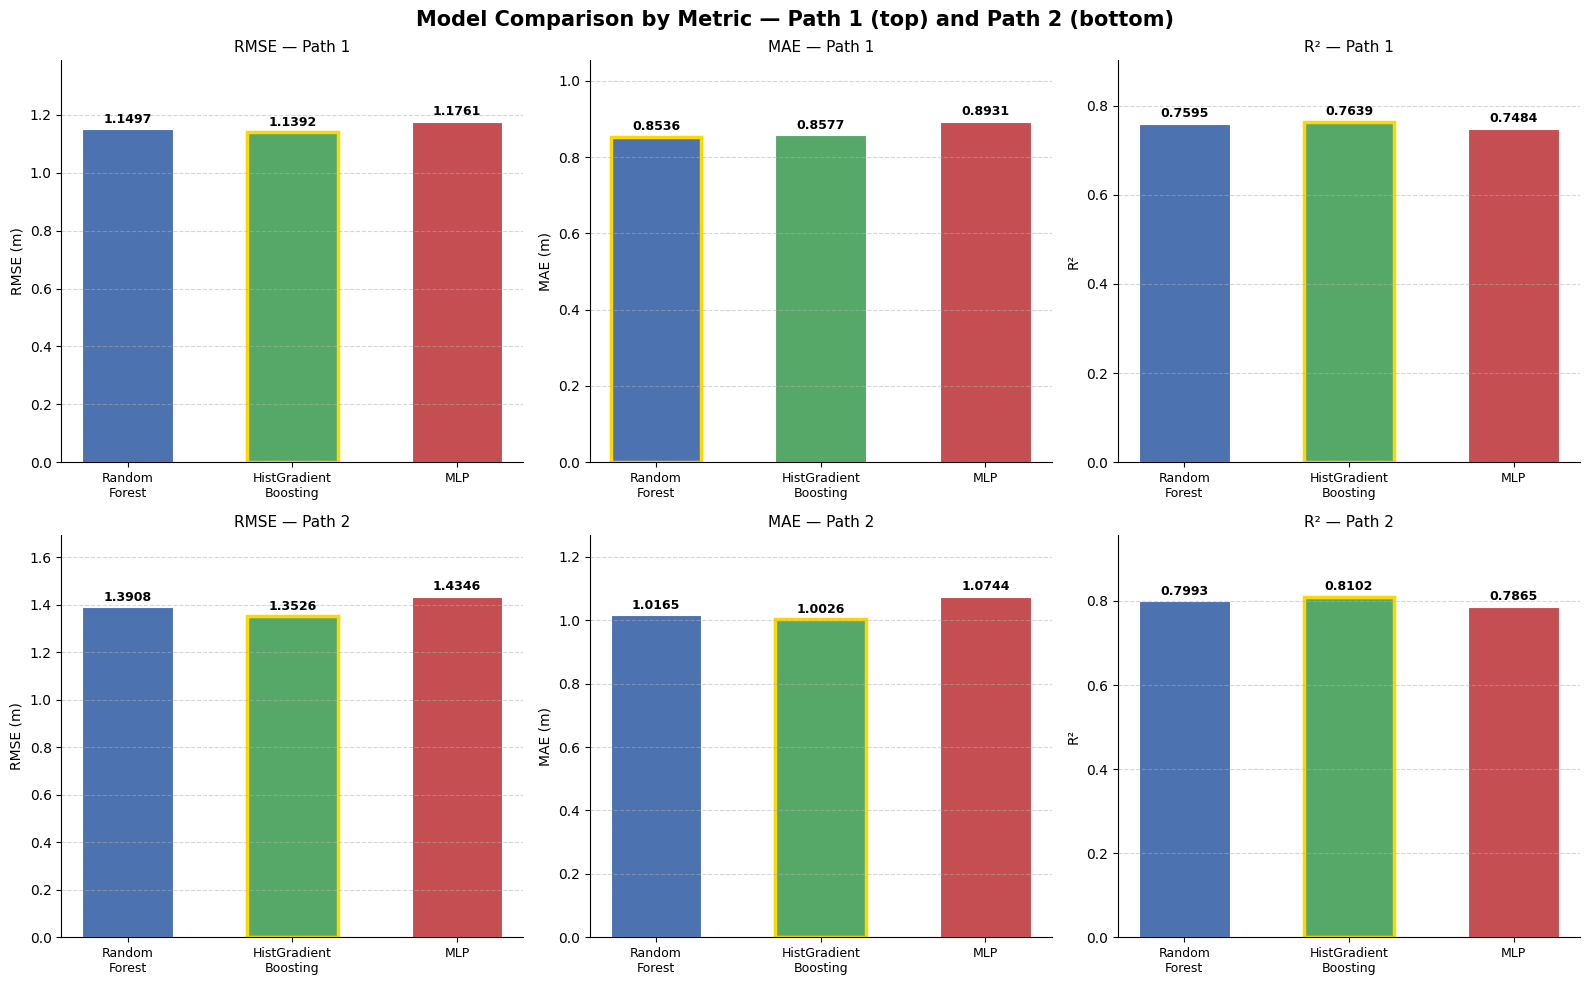

Best model highlighted in gold border. Lower RMSE/MAE and higher R² is better.


In [ ]:
model_names = ['Random\nForest', 'HistGradient\nBoosting', 'MLP']
x = np.arange(len(model_names))
bar_width = 0.25
colors_bar = ['#4C72B0', '#55A868', '#C44E52']

metrics = {
    'RMSE': {
        'Path 1': [rf_rmse1, hgb_rmse1, mlp_rmse1],
        'Path 2': [rf_rmse2, hgb_rmse2, mlp_rmse2],
        'ylabel': 'RMSE (m)',
        'lower_is_better': True,
    },
    'MAE': {
        'Path 1': [rf_mae1, hgb_mae1, mlp_mae1],
        'Path 2': [rf_mae2, hgb_mae2, mlp_mae2],
        'ylabel': 'MAE (m)',
        'lower_is_better': True,
    },
    'R²': {
        'Path 1': [rf_r21, hgb_r21, mlp_r21],
        'Path 2': [rf_r22, hgb_r22, mlp_r22],
        'ylabel': 'R²',
        'lower_is_better': False,
    },
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Comparison by Metric — Path 1 (top) and Path 2 (bottom)', fontsize=15, fontweight='bold')

for col_idx, (metric_name, metric_data) in enumerate(metrics.items()):
    for row_idx, path_label in enumerate(['Path 1', 'Path 2']):
        ax = axes[row_idx, col_idx]
        values = metric_data[path_label]
        bars = ax.bar(x, values, width=bar_width * 2.2, color=colors_bar, edgecolor='white', linewidth=0.8)

        # Annotate each bar with its value
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (max(values) * 0.01),
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold'
            )

        # Highlight the best bar
        best_idx = int(np.argmin(values) if metric_data['lower_is_better'] else np.argmax(values))
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(2.5)

        ax.set_title(f'{metric_name} — {path_label}', fontsize=11)
        ax.set_ylabel(metric_data['ylabel'], fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, fontsize=9)
        ax.set_ylim(0, max(values) * 1.18)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('regression_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Best model highlighted in gold border. Lower RMSE/MAE and higher R² is better.')

### Save Best Regression Model

HistGradientBoosting achieved the best overall performance across both paths.
It is saved to disk so the end-to-end pipeline notebook can load it directly without retraining.

> **Note on the NLOS feature:** The last column of `X_train` / `X_test` is the **ground-truth NLOS label**
> appended during preprocessing. This is correct for supervised training — the model learns how the true
> channel condition (LOS vs NLOS) affects path distance. At inference time (see `pipeline.ipynb`),
> this column is replaced by the **classifier's predicted NLOS label**, closing the pipeline loop.

In [5]:
import joblib

joblib.dump(hgb, "hgb_regressor.pkl")
print("HGB regressor saved successfully.")

HGB regressor saved successfully.


## 4. Impact of Predicted vs True NLOS Label

During training, the **ground-truth NLOS label** is appended as the last feature column —
the regressor learns how the confirmed channel condition (LOS vs NLOS) correlates with
path distance.

At inference time the ground-truth label is unavailable. Instead, the **Gradient Boosting
Classifier** (saved in `gradient_boosting_model.pkl`) predicts the NLOS label from the
same CIR features, and that prediction is substituted into the feature matrix.

This section quantifies the performance gap introduced by classifier errors propagating
into the regressor — i.e. the real-world pipeline cost compared to the oracle baseline above.

In [6]:
import joblib

# ── Load classifier and raw classification features ──────────────────────────
clf = joblib.load("gradient_boosting_model.pkl")

clf_data    = np.load("classification_data.npz")
X_test_clf  = clf_data["X_test"]   # (8400, 103) — no NLOS column
y_test_nlos = clf_data["y_test"]   # (8400,)     — true labels (for reference only)

# ── Stage 1: predict NLOS labels ─────────────────────────────────────────────
nlos_pred = clf.predict(X_test_clf)   # (8400,)

clf_acc = np.mean(nlos_pred == y_test_nlos)
print(f"Classifier accuracy on test set: {clf_acc:.4f}")
print(f"Misclassified samples          : {(nlos_pred != y_test_nlos).sum()} / {len(y_test_nlos)}")
print()

# ── Build X_test with predicted NLOS in last column ──────────────────────────
X_test_pred_nlos = np.hstack([X_test_clf, nlos_pred.reshape(-1, 1)])   # (8400, 104)

# ── Run best model (HGB) with predicted-NLOS features ────────────────────────
hgb_preds_pred = hgb.predict(X_test_pred_nlos)

hgb_rmse1_pred = np.sqrt(mean_squared_error(y_test[:, 0], hgb_preds_pred[:, 0]))
hgb_mae1_pred  = mean_absolute_error(y_test[:, 0], hgb_preds_pred[:, 0])
hgb_r21_pred   = r2_score(y_test[:, 0], hgb_preds_pred[:, 0])

hgb_rmse2_pred = np.sqrt(mean_squared_error(y_test[:, 1], hgb_preds_pred[:, 1]))
hgb_mae2_pred  = mean_absolute_error(y_test[:, 1], hgb_preds_pred[:, 1])
hgb_r22_pred   = r2_score(y_test[:, 1], hgb_preds_pred[:, 1])

# ── Comparison table ──────────────────────────────────────────────────────────
print("HGB Regressor — True NLOS (oracle) vs Predicted NLOS (pipeline)")
print("=" * 65)
print(f"{'Metric':<8} {'True-NLOS P1':>14} {'Pred-NLOS P1':>14} {'Delta P1':>10}")
print("-" * 48)
print(f"{'RMSE':<8} {hgb_rmse1:>14.4f} {hgb_rmse1_pred:>14.4f} {hgb_rmse1_pred - hgb_rmse1:>+10.4f}")
print(f"{'MAE':<8} {hgb_mae1:>14.4f} {hgb_mae1_pred:>14.4f} {hgb_mae1_pred - hgb_mae1:>+10.4f}")
print(f"{'R2':<8} {hgb_r21:>14.4f} {hgb_r21_pred:>14.4f} {hgb_r21_pred - hgb_r21:>+10.4f}")
print()
print(f"{'Metric':<8} {'True-NLOS P2':>14} {'Pred-NLOS P2':>14} {'Delta P2':>10}")
print("-" * 48)
print(f"{'RMSE':<8} {hgb_rmse2:>14.4f} {hgb_rmse2_pred:>14.4f} {hgb_rmse2_pred - hgb_rmse2:>+10.4f}")
print(f"{'MAE':<8} {hgb_mae2:>14.4f} {hgb_mae2_pred:>14.4f} {hgb_mae2_pred - hgb_mae2:>+10.4f}")
print(f"{'R2':<8} {hgb_r22:>14.4f} {hgb_r22_pred:>14.4f} {hgb_r22_pred - hgb_r22:>+10.4f}")

Classifier accuracy on test set: 0.8937
Misclassified samples          : 893 / 8400

HGB Regressor — True NLOS (oracle) vs Predicted NLOS (pipeline)
Metric     True-NLOS P1   Pred-NLOS P1   Delta P1
------------------------------------------------
RMSE             1.1392         1.2248    +0.0856
MAE              0.8577         0.9233    +0.0657
R2               0.7639         0.7271    -0.0368

Metric     True-NLOS P2   Pred-NLOS P2   Delta P2
------------------------------------------------
RMSE             1.3526         1.4259    +0.0733
MAE              1.0026         1.0596    +0.0570
R2               0.8102         0.7891    -0.0211


/home/xenonic/Documents/Github/CSC3105/.venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/xenonic/Documents/Github/CSC3105/.venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/xenonic/Documents/Github/CSC3105/.venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpic

## Visualization: True vs Predicted Distances

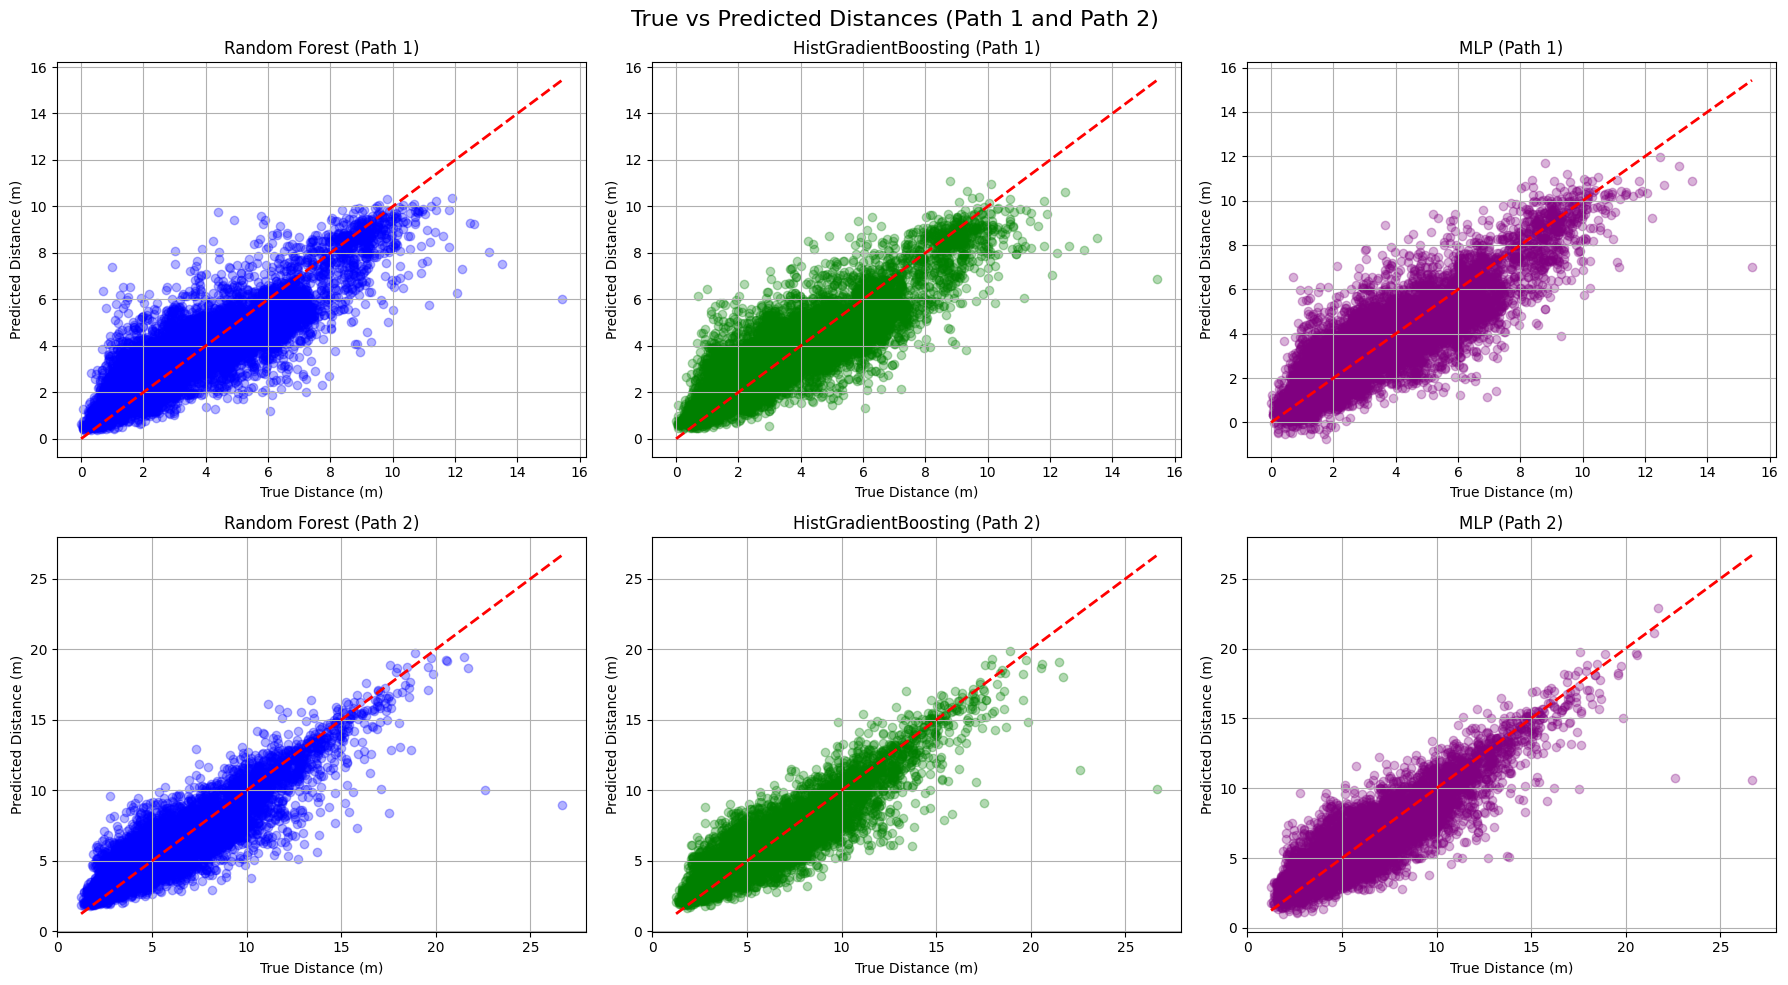

In [7]:
# Setup plots for actual vs predicted for both paths
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("True vs Predicted Distances (Path 1 and Path 2)", fontsize=16)

models = ['Random Forest', 'HistGradientBoosting', 'MLP']
preds = [rf_preds, hgb_preds, mlp_preds]
colors = ['blue', 'green', 'purple']

for i in range(3):
    # Path 1
    axes[0, i].scatter(y_test[:, 0], preds[i][:, 0], alpha=0.3, color=colors[i])
    axes[0, i].plot([y_test[:, 0].min(), y_test[:, 0].max()], [y_test[:, 0].min(), y_test[:, 0].max()], 'r--', lw=2)
    axes[0, i].set_title(f"{models[i]} (Path 1)")
    axes[0, i].set_xlabel("True Distance (m)")
    axes[0, i].set_ylabel("Predicted Distance (m)")
    axes[0, i].grid(True)
    
    # Path 2
    axes[1, i].scatter(y_test[:, 1], preds[i][:, 1], alpha=0.3, color=colors[i])
    axes[1, i].plot([y_test[:, 1].min(), y_test[:, 1].max()], [y_test[:, 1].min(), y_test[:, 1].max()], 'r--', lw=2)
    axes[1, i].set_title(f"{models[i]} (Path 2)")
    axes[1, i].set_xlabel("True Distance (m)")
    axes[1, i].set_ylabel("Predicted Distance (m)")
    axes[1, i].grid(True)

plt.tight_layout()
#plt.savefig('regression_actual_vs_predicted_multi.png', dpi=300)
plt.show()

## Visualization: Residual Plots
A residual plot evaluates the variance of the errors. Ideal residual plots have no distinct patterns and are centered tightly around 0.

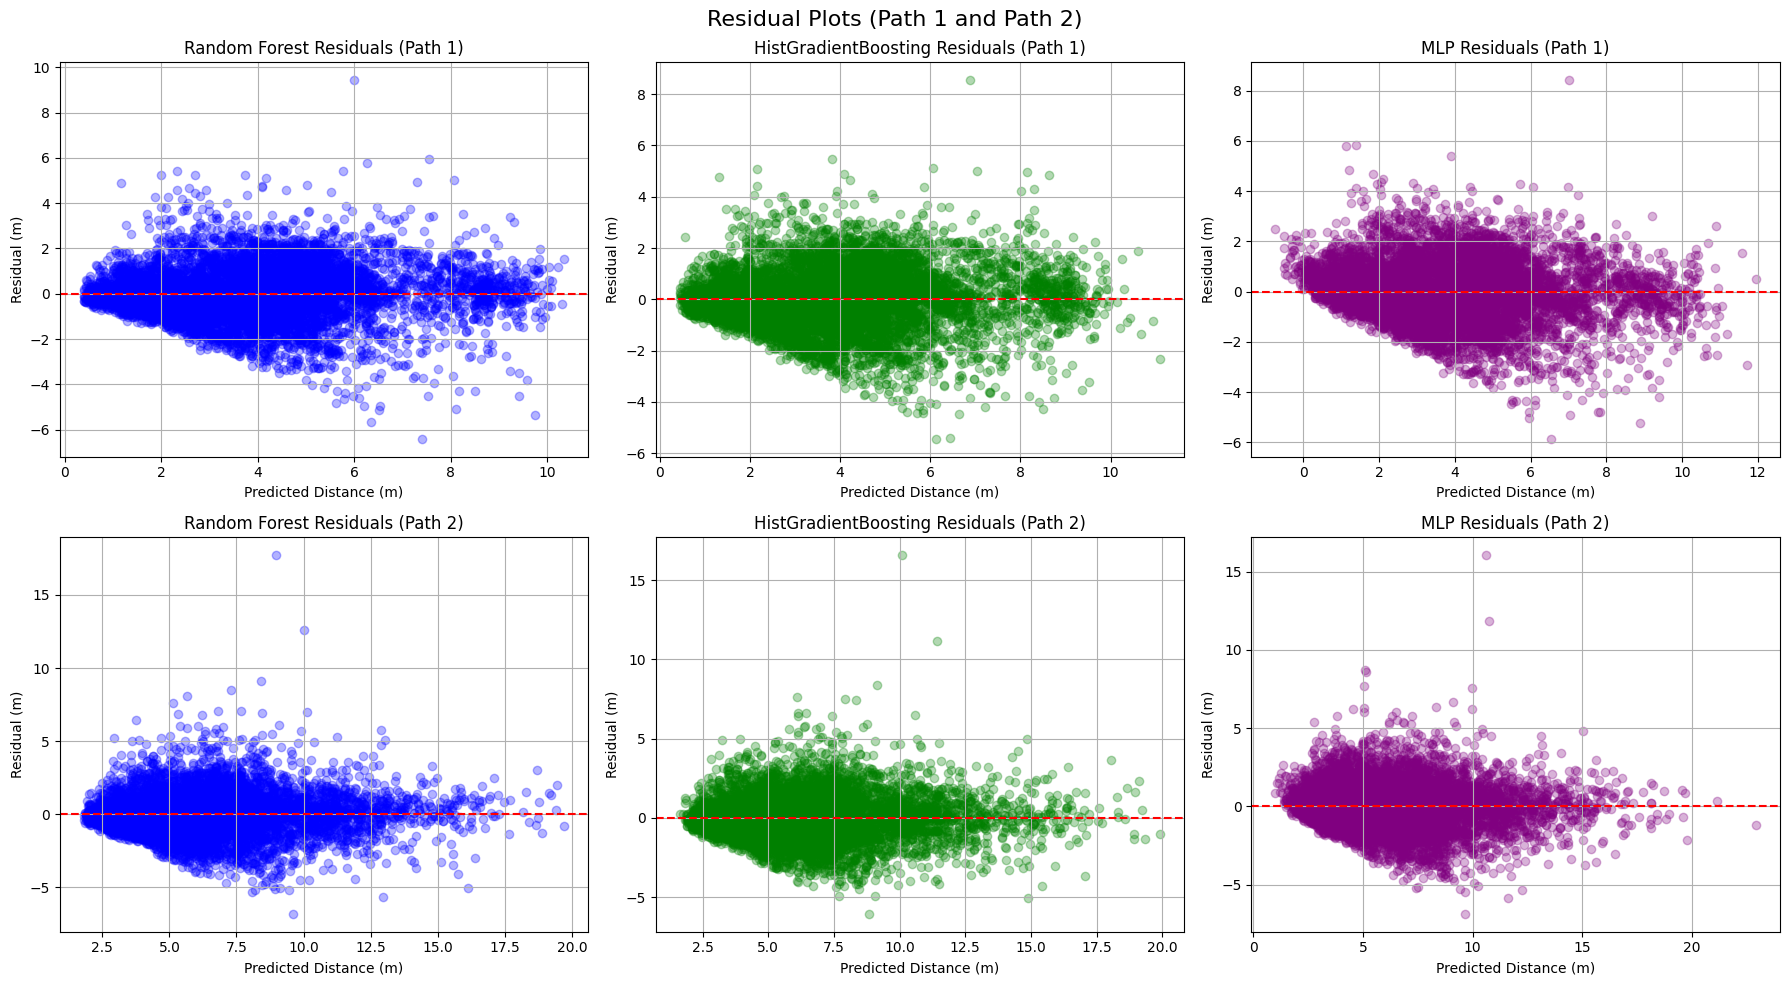

In [ ]:
# Compute Residuals for Path 1 and Path 2
rf_res_p1 = y_test[:, 0] - rf_preds[:, 0]
rf_res_p2 = y_test[:, 1] - rf_preds[:, 1]

hgb_res_p1 = y_test[:, 0] - hgb_preds[:, 0]
hgb_res_p2 = y_test[:, 1] - hgb_preds[:, 1]

mlp_res_p1 = y_test[:, 0] - mlp_preds[:, 0]
mlp_res_p2 = y_test[:, 1] - mlp_preds[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Residual Plots (Path 1 and Path 2)", fontsize=16)

res_p1 = [rf_res_p1, hgb_res_p1, mlp_res_p1]
res_p2 = [rf_res_p2, hgb_res_p2, mlp_res_p2]

for i in range(3):
    # Path 1
    axes[0, i].scatter(preds[i][:, 0], res_p1[i], alpha=0.3, color=colors[i])
    axes[0, i].axhline(y=0, color='r', linestyle='--')
    axes[0, i].set_title(f"{models[i]} Residuals (Path 1)")
    axes[0, i].set_xlabel("Predicted Distance (m)")
    axes[0, i].set_ylabel("Residual (m)")
    axes[0, i].grid(True)
    
    # Path 2
    axes[1, i].scatter(preds[i][:, 1], res_p2[i], alpha=0.3, color=colors[i])
    axes[1, i].axhline(y=0, color='r', linestyle='--')
    axes[1, i].set_title(f"{models[i]} Residuals (Path 2)")
    axes[1, i].set_xlabel("Predicted Distance (m)")
    axes[1, i].set_ylabel("Residual (m)")
    axes[1, i].grid(True)

plt.tight_layout()
#plt.savefig('regression_residuals_multi.png', dpi=300)
plt.show()